In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import glob

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)

adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(['leukemic blast'])
adata.uns['cell_type_colors'] = np.append(adata.uns['cell_type_colors'], ['#000000'])
## rename clusters in leukemic blast
adata.obs.loc[adata.obs['pheno_leiden'].isin([4,9,16,13,15,17]) & ~(adata.obs['cell_type'].isin(['B cell (non-HSPC)', 'T cell (non-HSPC)'])), 'cell_type'] = 'leukemic blast'
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()


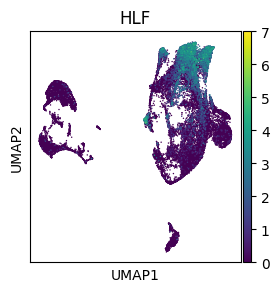

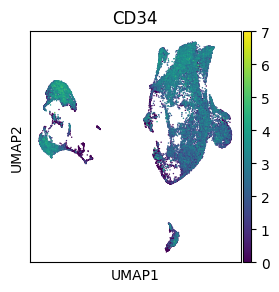

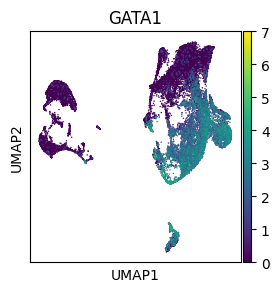

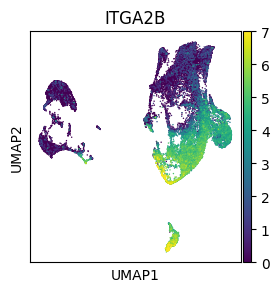

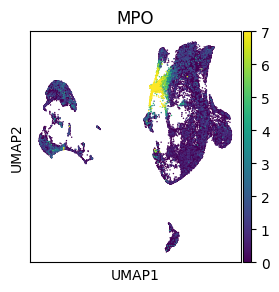

In [3]:
HSPC_markers = ['HLF','CD34','GATA1','ITGA2B','MPO']

for marker in HSPC_markers:
    fig,ax = plt.subplots(figsize=(3,3))
    sc.pl.umap(adata, color=marker, show=False, ax=ax, vmin=0, vmax=7)
    # Get current axes and rasterize scatter points
    ax = plt.gca()
    for coll in ax.collections:
        coll.set_rasterized(True)
    plt.savefig(f'../plots/marker_HSPC_{marker}_umap.pdf', bbox_inches='tight')


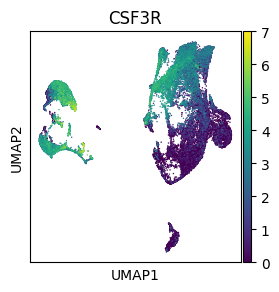

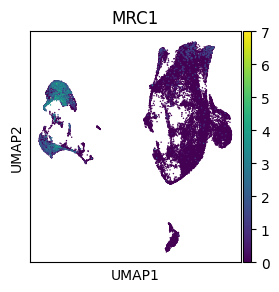

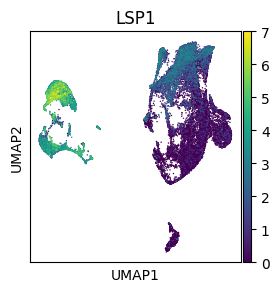

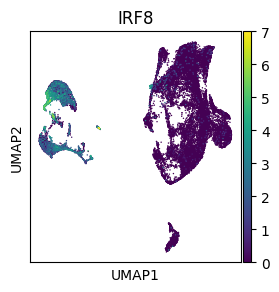

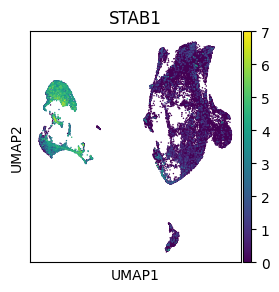

In [4]:
myeloid_markers = ['CSF3R', 'MRC1', 'LSP1', 'IRF8', 'STAB1']

for marker in myeloid_markers:
    fig,ax = plt.subplots(figsize=(3,3))
    sc.pl.umap(adata, color=marker, show=False, ax=ax, vmin=0, vmax=7)
    # Get current axes and rasterize scatter points
    ax = plt.gca()
    for coll in ax.collections:
        coll.set_rasterized(True)
    plt.savefig(f'../plots/marker_myeloid_{marker}_umap.pdf', bbox_inches='tight')
